# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [3]:
# Import the library
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt


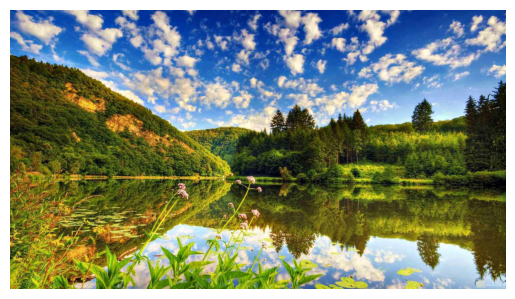

In [9]:
# ── Load image ────────────────────────────────────

img = Image.open('Nature.jpg')

plt.imshow(img)
plt.axis('off')
plt.show()

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [10]:
# Get the size of the image
width, height = img.size

# scaling factors

cx = 2
cy = 2


In [11]:
# ── 1. Increase size (scale ×2) ────────────────────

# Resize the image using PIL's built-in method

scaled_img = img.resize((width * cx, height * cy), Image.Resampling.LANCZOS)

In [12]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")

scaled_img.save("task1_1_scaled.jpg")

print("Original size:", img.size)
print("Scaled size:", scaled_img.size)


Original size: (1920, 1080)
Scaled size: (3840, 2160)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [13]:
cx = 2
cy = 1

In [14]:
non_uniform_img = img.resize(
    (width * cx, height * cy),
    Image.Resampling.LANCZOS
)

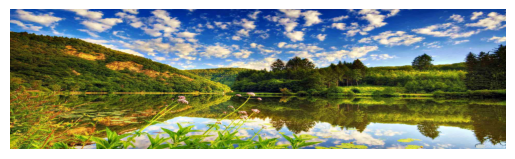

In [15]:
plt.imshow(non_uniform_img)
plt.axis('off')
plt.show()

### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

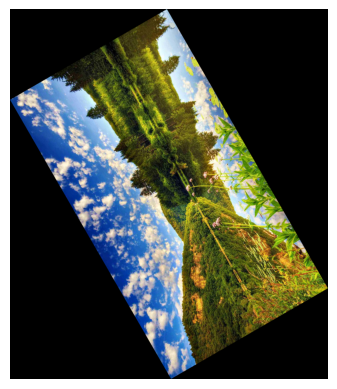

In [16]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")

rotated_img = img.rotate(120, expand=True)

rotated_img.save("task1_2_rotated.jpg")

plt.imshow(rotated_img)
plt.axis('off')
plt.show()

### 3. Shear

In [23]:
# -- c. Get the image dimensions ────────────────────

width, height = img.size
print(width, height)

1920 1080


In [24]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.

shear_factor = 0.5

In [25]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]

new_width = int(width + shear_factor * height)

sheared_img = img.transform(
    (new_width, height),
    Image.AFFINE,
    (1, shear_factor, 0, 0, 1, 0)
)


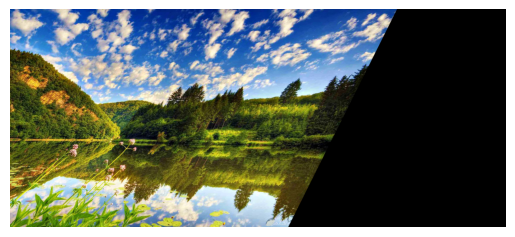

In [26]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 
sheared_img.save("task1_3_sheared.jpg")

plt.imshow(sheared_img)
plt.axis('off')
plt.show()

### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

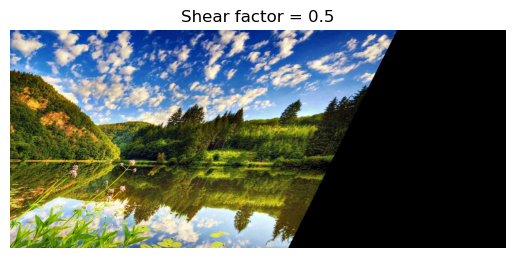

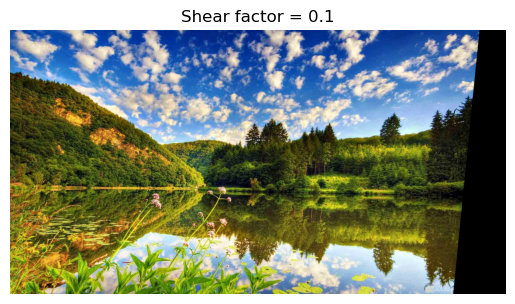

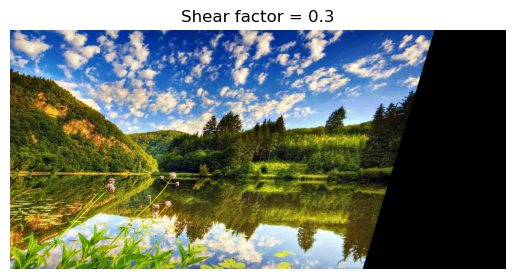

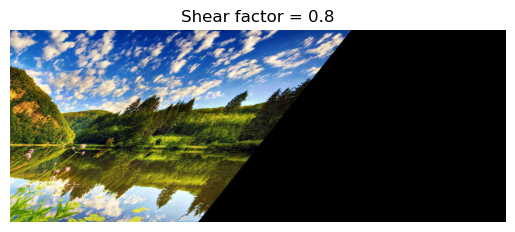

In [28]:
#Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

for factor in [0.5, 0.1, 0.3, 0.8]:
    new_width = int(width + factor * height)

    result = img.transform(
        (new_width, height),
        Image.AFFINE,
        (1, factor, 0, 0, 1, 0)
    )

    plt.imshow(result)
    plt.title("Shear factor = " + str(factor))
    plt.axis('off')
    plt.show()

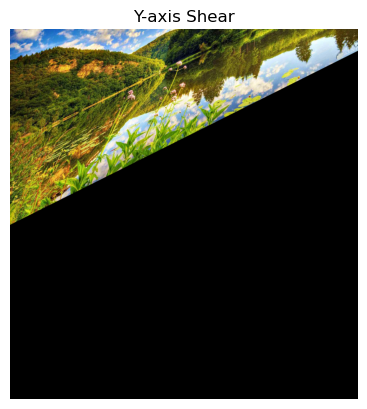

In [35]:
#Switch from X-axis to Y-axis shear matrix

shear_factor = 0.5

#—Update the canvas multiplier to match your new factor

new_height = int(height + shear_factor * width)

y_shear = img.transform(
    (width, new_height),
    Image.AFFINE,
    (1, 0, 0, shear_factor, 1, 0)
)

plt.imshow(y_shear)
plt.title("Y-axis Shear")
plt.axis('off')
plt.show()

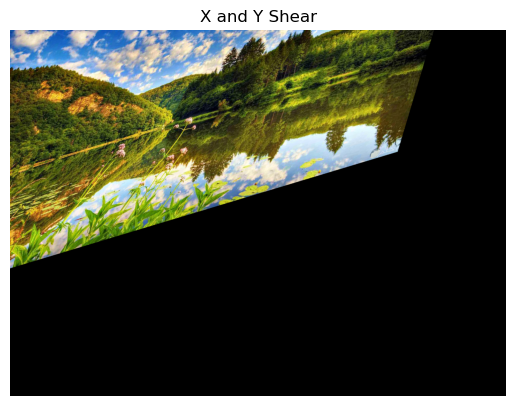

In [30]:
# Try combining X and Y shear in one matrix
# 3. Combine X and Y shear
x_shear = 0.3
y_shear = 0.3

new_width = int(width + x_shear * height)
new_height = int(height + y_shear * width)

xy_shear = img.transform(
    (new_width, new_height),
    Image.AFFINE,
    (1, x_shear, 0, y_shear, 1, 0)
)

plt.imshow(xy_shear)
plt.title("X and Y Shear")
plt.axis('off')
plt.show()

# Intensity Transformations
Negative · Log · Power Law (Gamma)

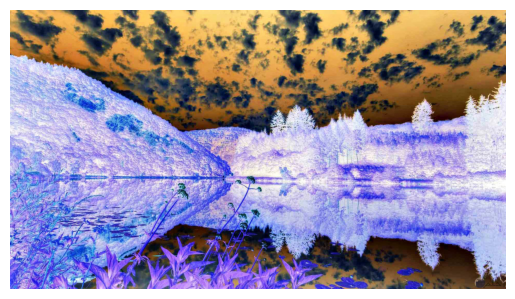

In [31]:

# ── 1. Negative ──────────────────────────────────── 
# Method 1: NumPy array manipulation

img_array = np.array(img)

negative_array = 255 - img_array

negative_img = Image.fromarray(negative_array)

plt.imshow(negative_img)
plt.axis('off')
plt.show()



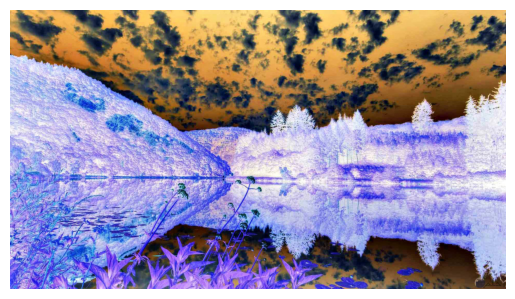

In [32]:
# Method 2: PIL's ImageOps
negative_img2 = ImageOps.invert(img)

plt.imshow(negative_img2)
plt.axis('off')
plt.show()

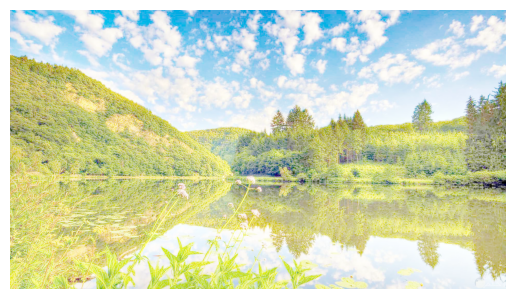

In [37]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)


img_array = np.array(img).astype(float)

c = 255 / np.log(1 + 255)

# Apply the log transformation to each pixel
log_array = c * np.log(1 + img_array)
log_array = np.uint8(log_array)

log_img = Image.fromarray(log_array)

plt.imshow(log_img)
plt.axis('off')
plt.show()


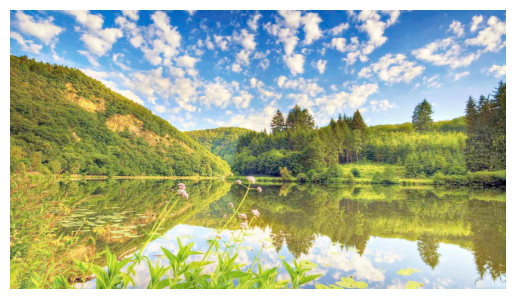

In [38]:

# ── 3. Power-law / Gamma correction ───────────────

img_array = np.array(img)

gamma = 0.5

gamma_array = 255 * (img_array / 255) ** gamma
gamma_array = np.uint8(gamma_array)

gamma_img = Image.fromarray(gamma_array)

plt.imshow(gamma_img)
plt.axis('off')
plt.show()